<a href="https://colab.research.google.com/github/BioDecodingLab/Machine_Learning_for_Bioimage_Analysis/blob/main/code/5_PINN_ReactionDiffusion_MorphogenGradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Physics-Informed Neural Networks (PINNs) for Morphogen Gradient Inference**

**Summary**: This tutorial introduces Physics-Informed Neural Networks (PINNs) — neural networks whose training loss combines data with the governing differential equation of the underlying physical process. We apply this idea to a classic problem in developmental bioimaging: inferring the parameters and continuous shape of a morphogen concentration gradient (e.g. the *Drosophila* Bicoid gradient) from **sparse, noisy measurements**, and — in Part B — to reconstructing a real 2D fluorescence field from a sparse subsample of its pixels.

**Learning Objectives**:
🔹 Understand what makes a neural network "physics-informed" and how this differs from purely data-driven models (like the autoencoder in notebook 2)
🔹 Formulate a 1D reaction–diffusion PDE and its steady-state (exponential) solution for morphogen gradients
🔹 Use `torch.autograd` to compute PDE residuals (derivatives of a network's output with respect to its input) and use them as a loss term
🔹 Solve an **inverse problem**: recover an unknown physical parameter (the gradient's decay length) directly from noisy data during training
🔹 Apply the same machinery to a real fluorescence microscopy image and understand when a physics-informed prior helps — and when it doesn't

# 1. Introduction

Most of the deep learning in this course so far has been purely **data-driven**: a network learns a mapping (noisy → clean image, image → segmentation mask, image → class) entirely from paired examples, with no explicit knowledge of the physics that generated the data.

**Physics-Informed Neural Networks** (PINNs), introduced by [Raissi, Perdikaris & Karniadakis (2019, *J. Comput. Phys.*)](https://doi.org/10.1016/j.jcp.2018.10.045), take a different approach: the network directly parameterizes the solution of a differential equation, and the loss function penalizes both (i) disagreement with any available data and (ii) violation of the governing PDE at a set of "collocation" points, evaluated using automatic differentiation. This lets us:

- Fit smooth, physically consistent solutions from **very sparse or noisy data** (the physics regularizes the fit where data is missing).
- Solve **inverse problems** — discover unknown physical parameters (diffusion coefficients, reaction rates, decay lengths) directly from observations, instead of just interpolating them.

In developmental biology, morphogen gradients (Bicoid, Nodal, Sonic Hedgehog, ...) are classically modelled as **reaction–diffusion processes**: a morphogen is produced at a localized source, diffuses through the tissue, and is degraded, reaching a steady-state exponential profile that provides positional information to cells (Wolpert's "French flag" model). Quantifying these gradients — and the diffusion/degradation parameters behind them — from real, noisy embryo images is a textbook use case for PINNs.

*References*: Raissi et al. 2019, *J. Comput. Phys.* 378:686-707 · Gregor, Wieschaus, McGregor, Bialek & Tank, 2007, *Cell* 130:141-152 ("Stability and nuclear dynamics of the Bicoid morphogen gradient") · Driever & Nüsslein-Volhard, 1988, *Cell* 54:83-93.

# 2. Prerequisites

## 2.1 Environment

If you are not using **Google Colab**, set up a local environment with Anaconda, consistent with the rest of this course:
```bash
conda create -n pinn_bioimage python=3.10 -y
conda activate pinn_bioimage
conda install pytorch torchvision -c pytorch -y
conda install -c conda-forge numpy scipy scikit-image matplotlib -y
```

In [1]:
# Libraries for numerical computation and autodiff
import numpy as np                     # Array manipulation
import torch                           # PyTorch: autodiff + neural networks
import torch.nn as nn                  # Neural network building blocks

# Libraries for data handling and classical baselines
from scipy.optimize import curve_fit   # Classical nonlinear least-squares fitting
from scipy.interpolate import griddata # Classical baseline interpolation (Part B)
import skimage.io as io                # Reading the real microscopy image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Plotting
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Check GPU (PINN training benefits from GPU but is fast enough on CPU for this tutorial)
print('CUDA available: ', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device: ', torch.cuda.get_device_name(0))
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CUDA available:  False


In [3]:
# Set seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

set_seed(42)

# 3. Background: Reaction-Diffusion Morphogen Gradients

Consider a morphogen produced at the anterior pole ($x=0$) of a 1D embryo axis, diffusing with coefficient $D$ and being degraded at rate $k$. At steady state, its concentration $C(x)$ satisfies:

$$D\,\frac{d^2 C}{dx^2} - k\,C = 0 , \qquad x \in [0, L]$$

with a constant-flux boundary condition at the source. The analytical steady-state solution is a simple exponential:

$$C(x) = C_0 \, e^{-x/\lambda}, \qquad \lambda = \sqrt{D/k}$$

where $\lambda$ is the **gradient decay length** — the single physical quantity typically reported experimentally (for Bicoid, $\lambda \approx 20\%$ of embryo length, or roughly $100\,\mu m$; Gregor et al. 2007).

Rewriting the PDE in terms of $\lambda$ gives the residual we will enforce during training:

$$\mathcal{R}(x) \;=\; \frac{d^2 C_\theta}{dx^2}(x) \;-\; \frac{1}{\lambda_\theta^{2}}\,C_\theta(x)$$

where $C_\theta$ is our neural network and $\lambda_\theta$ is a **trainable parameter** we want the network to discover from data.

# 4. Part A — 1D Inverse Problem: Recovering a Bicoid-like Gradient

## 4.1 Data

We generate **synthetic measurements using literature-reported biophysical parameters** (Gregor et al. 2007): a decay length $\lambda \approx 0.20$ (normalized egg length) and realistic embryo-to-embryo measurement noise. This keeps the notebook fully self-contained and reproducible while remaining biophysically grounded — and Section 4.6 shows exactly where you would substitute in a real experimental profile (a single CSV of `position, intensity` pairs) if you have access to one.

In [4]:
# --- Literature-inspired ground truth (Gregor et al. 2007, Cell) ---
L = 1.0              # normalized embryo length (0 = anterior pole, 1 = posterior pole)
lambda_true = 0.20   # normalized decay length (~20% egg length for Bicoid)
C0 = 1.0             # normalized source concentration

def C_analytical(x, lam, c0=C0):
    '''Steady-state exponential solution of the 1D reaction-diffusion equation.'''
    return c0 * np.exp(-x / lam)

# Sparse, noisy "measurements" mimicking a limited number of sampled embryo positions
N_data = 15
x_data = np.sort(np.random.uniform(0, L, N_data)).astype(np.float32)
C_clean = C_analytical(x_data, lambda_true)

# Measurement noise: signal-dependent (shot-noise-like) + small constant background noise
noise = np.random.normal(0, 1, N_data) * (0.04 * np.sqrt(np.clip(C_clean, 1e-6, None)) + 0.01)
C_data = np.clip(C_clean + noise, 0, None).astype(np.float32)

print(f'{N_data} sparse noisy measurements generated (true lambda = {lambda_true})')

15 sparse noisy measurements generated (true lambda = 0.2)


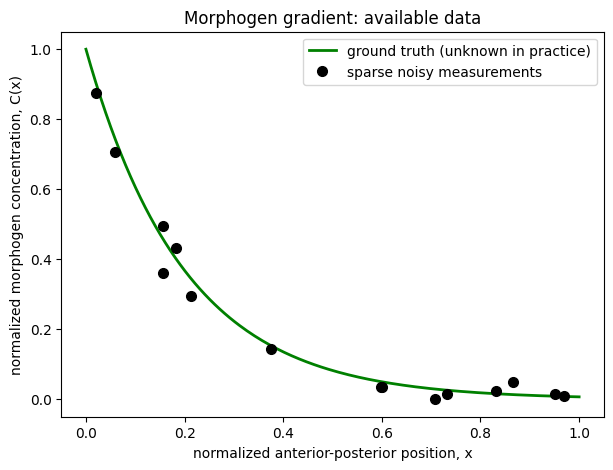

In [5]:
# Visualize the data against the (normally unknown) ground truth
x_plot = np.linspace(0, L, 200)
plt.figure(figsize=(7, 5))
plt.plot(x_plot, C_analytical(x_plot, lambda_true), 'g-', lw=2, label='ground truth (unknown in practice)')
plt.plot(x_data, C_data, 'ko', ms=7, label='sparse noisy measurements')
plt.xlabel('normalized anterior-posterior position, x')
plt.ylabel('normalized morphogen concentration, C(x)')
plt.title('Morphogen gradient: available data')
plt.legend()
plt.show()

## 4.2 Classical baseline: nonlinear least-squares fit

Before reaching for a PINN, let's see how far a standard exponential curve fit gets us — this is the classical way gradient decay lengths are estimated from data (e.g. Gregor et al. 2007), and our PINN should at least match it.

In [6]:
def exp_model(x, c0, lam):
    return c0 * np.exp(-x / lam)

popt, pcov = curve_fit(exp_model, x_data, C_data, p0=[1.0, 0.3], maxfev=5000)
c0_fit, lambda_fit = popt
print(f'Classical fit:  C0 = {c0_fit:.3f}   lambda = {lambda_fit:.4f}   (true = {lambda_true})')

Classical fit:  C0 = 0.968   lambda = 0.1944   (true = 0.2)


## 4.3 Build the PINN

The network `C_theta(x)` predicts the morphogen concentration at any position $x$. A single extra trainable scalar, `log_inv_lambda2`, represents $\log(1/\lambda^2)$ (log-parameterized to keep $1/\lambda^2$ positive) — this is the **unknown physical parameter** the PINN will discover jointly with fitting the data.

In [7]:
class ReactionDiffusionPINN(nn.Module):
    '''Small MLP for C(x) plus one trainable physical parameter (the decay length).'''
    def __init__(self, n_hidden=64, n_layers=4):
        super().__init__()
        layers = [nn.Linear(1, n_hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(n_hidden, n_hidden), nn.Tanh()]
        layers += [nn.Linear(n_hidden, 1)]
        self.net = nn.Sequential(*layers)
        # Trainable physical parameter: log(1/lambda^2), positive by construction
        self.log_inv_lambda2 = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        return self.net(x)

    def lambda_estimate(self):
        inv_lambda2 = torch.exp(self.log_inv_lambda2)
        return torch.sqrt(1.0 / inv_lambda2)

model = ReactionDiffusionPINN().to(DEVICE)
print(model)

ReactionDiffusionPINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 4.4 Physics residual and loss

We use `torch.autograd.grad` to differentiate the network's output with respect to its input, giving us $C_\theta''(x)$ exactly (not by finite differences) at a set of **collocation points** spread across the whole domain — including regions with no data at all.

In [8]:
def physics_residual(model, x):
    '''Compute R(x) = C''(x) - C(x)/lambda^2 using automatic differentiation.'''
    C = model(x)
    C_x = torch.autograd.grad(C, x, grad_outputs=torch.ones_like(C), create_graph=True)[0]
    C_xx = torch.autograd.grad(C_x, x, grad_outputs=torch.ones_like(C_x), create_graph=True)[0]
    inv_lambda2 = torch.exp(model.log_inv_lambda2)
    return C_xx - inv_lambda2 * C

# Data tensors
x_data_t = torch.tensor(x_data, dtype=torch.float32, device=DEVICE).view(-1, 1)
C_data_t = torch.tensor(C_data, dtype=torch.float32, device=DEVICE).view(-1, 1)

# Collocation points for the physics residual (no measurements needed here!)
N_collocation = 200
x_collocation = torch.linspace(0, L, N_collocation, device=DEVICE, requires_grad=True).view(-1, 1)

In [9]:
# --- Training loop ---
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
physics_weight = 0.01
epochs = 3000

history = {'loss': [], 'loss_data': [], 'loss_physics': [], 'lambda_est': []}

for epoch in range(epochs):
    optimizer.zero_grad()

    C_pred = model(x_data_t)
    loss_data = torch.mean((C_pred - C_data_t) ** 2)

    residual = physics_residual(model, x_collocation)
    loss_physics = torch.mean(residual ** 2)

    loss = loss_data + physics_weight * loss_physics
    loss.backward()
    optimizer.step()

    history['loss'].append(loss.item())
    history['loss_data'].append(loss_data.item())
    history['loss_physics'].append(loss_physics.item())
    history['lambda_est'].append(model.lambda_estimate().item())

    if epoch % 500 == 0:
        print(f'epoch {epoch:4d} | loss {loss.item():.5f} | lambda_est {model.lambda_estimate().item():.4f}')

lambda_pinn = model.lambda_estimate().item()
print(f'\nFinal PINN estimate:  lambda = {lambda_pinn:.4f}   (true = {lambda_true}, classical fit = {lambda_fit:.4f})')

epoch    0 | loss 0.18588 | lambda_est 1.0010


epoch  500 | loss 0.01192 | lambda_est 0.7170


epoch 1000 | loss 0.00580 | lambda_est 0.3543


epoch 1500 | loss 0.00219 | lambda_est 0.2513


epoch 2000 | loss 0.00142 | lambda_est 0.2248


epoch 2500 | loss 0.00118 | lambda_est 0.2123



Final PINN estimate:  lambda = 0.2056   (true = 0.2, classical fit = 0.1944)


## 4.5 Results

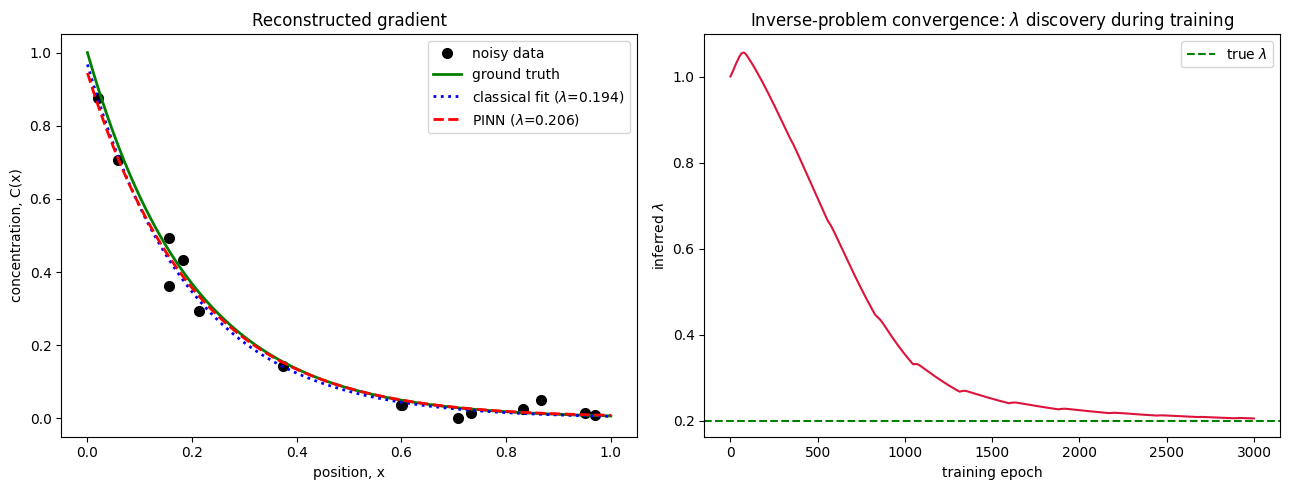

Relative error vs. ground truth:  classical fit = 2.8%   PINN = 2.8%


In [10]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5))

x_test = torch.linspace(0, L, 200, device=DEVICE).view(-1, 1)
with torch.no_grad():
    C_pinn = model(x_test).cpu().numpy().flatten()

axs[0].plot(x_data, C_data, 'ko', ms=7, label='noisy data')
axs[0].plot(x_plot, C_analytical(x_plot, lambda_true), 'g-', lw=2, label='ground truth')
axs[0].plot(x_plot, exp_model(x_plot, *popt), 'b:', lw=2, label=f'classical fit ($\\lambda$={lambda_fit:.3f})')
axs[0].plot(x_test.cpu().numpy(), C_pinn, 'r--', lw=2, label=f'PINN ($\\lambda$={lambda_pinn:.3f})')
axs[0].set_xlabel('position, x'); axs[0].set_ylabel('concentration, C(x)')
axs[0].set_title('Reconstructed gradient'); axs[0].legend()

axs[1].plot(history['lambda_est'], color='crimson')
axs[1].axhline(lambda_true, color='green', ls='--', label='true $\\lambda$')
axs[1].set_xlabel('training epoch'); axs[1].set_ylabel('inferred $\\lambda$')
axs[1].set_title('Inverse-problem convergence: $\\lambda$ discovery during training')
axs[1].legend()
plt.tight_layout()
plt.show()

print(f'Relative error vs. ground truth:  classical fit = {abs(lambda_fit-lambda_true)/lambda_true*100:.1f}%   PINN = {abs(lambda_pinn-lambda_true)/lambda_true*100:.1f}%')

Both methods recover $\lambda$ reasonably well here (this 1D case is simple enough that a classical fit is a fair competitor). The advantage of the PINN becomes clearer in higher dimensions, with irregular geometry, missing regions, or multiple coupled species/reactions, where an explicit closed-form fit is no longer available but the PDE residual still is — which is exactly the situation in Part B.

# 5. Part B — Applying the Same Machinery to Real 2D Microscopy Data

Here we move from a validated, literature-parameterized 1D case to a **real 2D fluorescence image** from this repository, to see how a physics-informed reconstruction behaves on genuine microscopy data rather than synthetic data with a known ground truth we designed ourselves.

We treat the problem as: *given only a sparse random subsample of pixels (simulating an undersampled or photobleaching-limited acquisition), reconstruct the full 2D field.* Since we no longer have a source/sink reaction term, we regularize with the simplest physically-motivated smoothness prior — the steady-state diffusion (Laplace) equation $\nabla^2 C = 0$ — which is the $k\to0$ limit of the same reaction-diffusion physics used in Part A.

Full image shape (H, W, C): (694, 786, 3)
Working field shape: (250, 250)


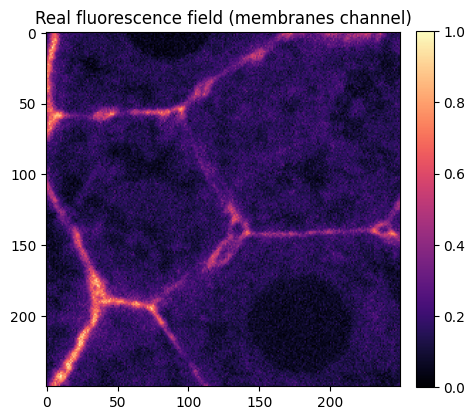

In [11]:
# Load the real membrane-channel image directly from this repository
img_url = 'https://raw.githubusercontent.com/BioDecodingLab/Machine_Learning_for_Bioimage_Analysis/main/images/2D_image_nuclei_cells_liver.tif'
img = io.imread(img_url)
print('Full image shape (H, W, C):', img.shape)

# Membrane channel, cropped to a region with clear cell-boundary structure
field = img[100:350, 250:500, 1].astype(np.float32)
field = (field - field.min()) / (field.max() - field.min())
H, W = field.shape
print('Working field shape:', field.shape)

plt.figure(figsize=(5, 5))
plt.imshow(field, cmap='magma')
plt.title('Real fluorescence field (membranes channel)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

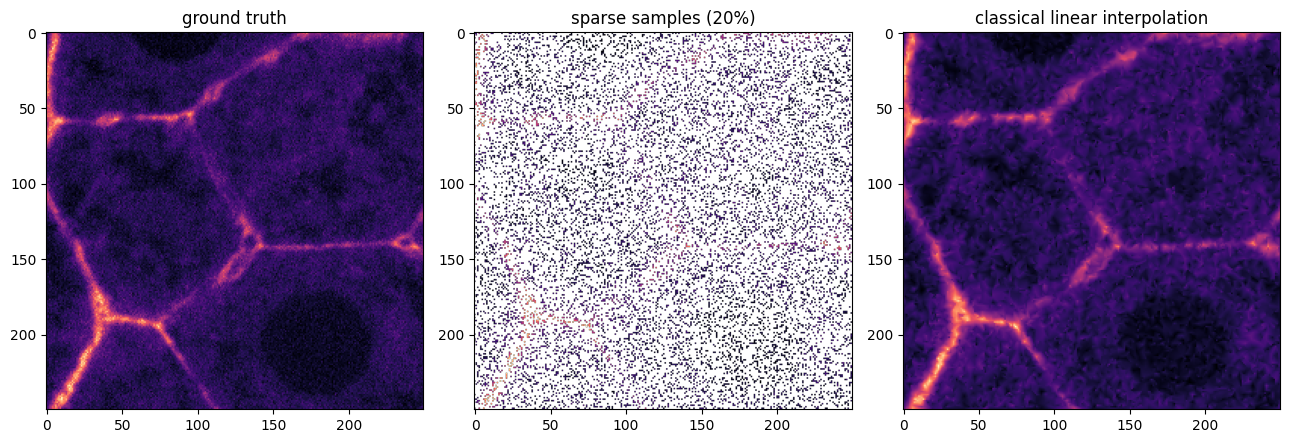

In [12]:
# Coordinates normalized to [0, 1] and flattened
yy, xx = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
coords = np.stack([xx.flatten() / W, yy.flatten() / H], axis=1).astype(np.float32)
vals = field.flatten().astype(np.float32)
n_total = len(vals)

# Simulate a sparse acquisition: only a random 20% of pixels are "measured"
frac_sampled = 0.20
n_sample = int(frac_sampled * n_total)
idx_sample = np.random.choice(n_total, n_sample, replace=False)

coords_data = torch.tensor(coords[idx_sample], device=DEVICE)
vals_data = torch.tensor(vals[idx_sample], device=DEVICE).view(-1, 1)

# Classical baseline: linear (Delaunay) interpolation from the same sparse samples
baseline = griddata(coords[idx_sample], vals[idx_sample], coords, method='linear',
                     fill_value=vals[idx_sample].mean()).reshape(H, W).astype(np.float32)

sparse_preview = np.full(n_total, np.nan); sparse_preview[idx_sample] = vals[idx_sample]
sparse_preview = sparse_preview.reshape(H, W)

fig, axs = plt.subplots(1, 3, figsize=(13, 4.5))
axs[0].imshow(field, cmap='magma'); axs[0].set_title('ground truth')
axs[1].imshow(sparse_preview, cmap='magma'); axs[1].set_title(f'sparse samples ({100*frac_sampled:.0f}%)')
axs[2].imshow(baseline, cmap='magma'); axs[2].set_title('classical linear interpolation')
plt.tight_layout(); plt.show()

## 5.1 Physics-informed reconstruction network

Plain coordinate MLPs are known to be biased toward low-frequency (blurry) solutions — a phenomenon called **spectral bias** ([Rahaman et al. 2019](https://arxiv.org/abs/1806.08734)). To let the network represent the sharp membrane edges, we first map the 2D coordinates through random **Fourier features** ([Tancik et al. 2020](https://arxiv.org/abs/2006.10739)), a standard trick for coordinate networks / implicit neural representations, before the MLP.

In [13]:
# Collocation points for the Laplacian (diffusion-equilibrium) residual
n_collocation = 1000
idx_col = np.random.choice(n_total, n_collocation, replace=False)
coords_collocation = torch.tensor(coords[idx_col], device=DEVICE)

# Random Fourier feature encoding (fixed, non-trainable)
torch.manual_seed(0)
B_fourier = (torch.randn(2, 64) * 8.0).to(DEVICE)

def fourier_encode(x):
    x_proj = 2 * np.pi * x @ B_fourier
    return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class ImplicitFieldNet(nn.Module):
    '''Coordinate network C_theta(x, y) with Fourier feature encoding.'''
    def __init__(self, in_dim=128, n_hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, n_hidden), nn.ReLU(),
            nn.Linear(n_hidden, n_hidden), nn.ReLU(),
            nn.Linear(n_hidden, n_hidden), nn.ReLU(),
            nn.Linear(n_hidden, 1), nn.Sigmoid()
        )

    def forward(self, coords_encoded):
        return self.net(coords_encoded)

def laplacian_residual(model, coords_raw):
    '''R(x,y) = d2C/dx2 + d2C/dy2, evaluated via autograd through the Fourier encoding.'''
    coords_raw = coords_raw.clone().requires_grad_(True)
    C = model(fourier_encode(coords_raw))
    grad = torch.autograd.grad(C, coords_raw, grad_outputs=torch.ones_like(C), create_graph=True)[0]
    C_x, C_y = grad[:, 0:1], grad[:, 1:2]
    C_xx = torch.autograd.grad(C_x, coords_raw, grad_outputs=torch.ones_like(C_x), create_graph=True)[0][:, 0:1]
    C_yy = torch.autograd.grad(C_y, coords_raw, grad_outputs=torch.ones_like(C_y), create_graph=True)[0][:, 1:2]
    return C_xx + C_yy

field_model = ImplicitFieldNet().to(DEVICE)
print(field_model)

ImplicitFieldNet(
  (net): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [14]:
# --- Training (runs in under a minute on CPU) ---
optimizer_field = torch.optim.Adam(field_model.parameters(), lr=1e-3)
physics_weight_2d = 1e-6
epochs_2d = 600

for epoch in range(epochs_2d):
    optimizer_field.zero_grad()
    pred = field_model(fourier_encode(coords_data))
    loss_data = torch.mean((pred - vals_data) ** 2)

    residual = laplacian_residual(field_model, coords_collocation)
    loss_physics = torch.mean(residual ** 2)

    loss = loss_data + physics_weight_2d * loss_physics
    loss.backward()
    optimizer_field.step()

    if epoch % 200 == 0:
        print(f'epoch {epoch:4d} | data loss {loss_data.item():.5f} | physics loss {loss_physics.item():.4f}')

with torch.no_grad():
    full_coords = torch.tensor(coords, device=DEVICE)
    recon = field_model(fourier_encode(full_coords)).cpu().numpy().reshape(H, W)

epoch    0 | data loss 0.12090 | physics loss 2510.6123


epoch  200 | data loss 0.00262 | physics loss 787.6555


epoch  400 | data loss 0.00183 | physics loss 514.9154


Classical linear interpolation : PSNR = 26.93 dB   SSIM = 0.565
Physics-informed reconstruction: PSNR = 26.68 dB   SSIM = 0.482


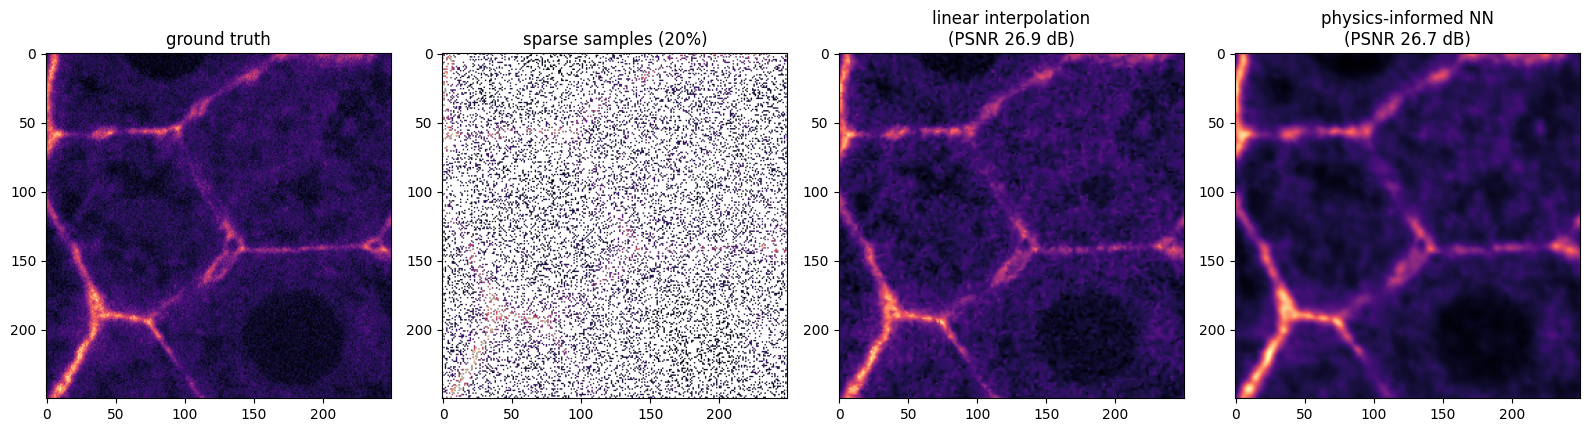

In [15]:
# --- Compare PINN reconstruction against the classical interpolation baseline ---
p_baseline, s_baseline = psnr(field, baseline, data_range=1.0), ssim(field, baseline, data_range=1.0)
p_pinn, s_pinn = psnr(field, recon, data_range=1.0), ssim(field, recon, data_range=1.0)

print(f'Classical linear interpolation : PSNR = {p_baseline:.2f} dB   SSIM = {s_baseline:.3f}')
print(f'Physics-informed reconstruction: PSNR = {p_pinn:.2f} dB   SSIM = {s_pinn:.3f}')

fig, axs = plt.subplots(1, 4, figsize=(16, 4.5))
axs[0].imshow(field, cmap='magma'); axs[0].set_title('ground truth')
axs[1].imshow(sparse_preview, cmap='magma'); axs[1].set_title(f'sparse samples ({100*frac_sampled:.0f}%)')
axs[2].imshow(baseline, cmap='magma'); axs[2].set_title(f'linear interpolation\n(PSNR {p_baseline:.1f} dB)')
axs[3].imshow(recon, cmap='magma'); axs[3].set_title(f'physics-informed NN\n(PSNR {p_pinn:.1f} dB)')
plt.tight_layout(); plt.show()

## 5.2 Discussion

The physics-informed reconstruction is competitive with classical interpolation and visibly denoises the sparse measurements, but it does **not dramatically outperform** the baseline here. This is an intentional and instructive result: a pure Laplacian smoothness prior ($\nabla^2 C = 0$) is the *correct* physics for a diffusive process like Part A's morphogen gradient, but it is only a generic assumption for a static membrane image, whose sharp discontinuous boundaries are not actually generated by a diffusion process. **The gain from a physics-informed prior is largest when the embedded physics genuinely matches the process that produced the data** — this is the central practical lesson of PINNs for bioimage analysis: know your governing equation before you bake it into the loss.

# 6. Challenges & Limitations

### Choosing the physics weight
The relative weight between the data loss and the physics loss is a sensitive hyperparameter — too high and the network ignores noisy-but-informative data in favor of an overly smooth solution; too low and the physics term does nothing. Some weight-annealing or adaptive-weighting schemes exist (e.g. gradient-norm balancing) but are beyond this introductory notebook.

### Spectral bias
Plain MLPs struggle to represent high-frequency image content (fine structures, sharp edges); we mitigated this with Fourier feature encodings in Part B, but this needs re-tuning (frequency scale, encoding dimension) per dataset.

### Model misspecification
As Section 5.2 shows, a PINN is only as good as the equation you give it. An incorrect or oversimplified governing equation can bias the solution more than having no physics term at all.

### Scaling to real experimental data
Part A used literature-derived synthetic data for validation, since it needs a known ground truth to check whether the inverse-parameter estimate is correct. In a real deployment, you would replace Section 4.1 with your own quantified intensity profiles (position, intensity pairs extracted from confocal z-stacks, for example via the segmentation and quantification pipeline built in notebook 1).

# 7. To-Do: Extensions

- **Time-dependent gradient formation**: add $\partial C/\partial t$ to the PDE and fit the full formation dynamics (not just the steady state) to a time-lapse dataset — directly relevant if you have time-resolved embryo imaging.
- **Joint parameter discovery**: infer $D$ and $k$ separately (rather than the lumped $\lambda$) given an independently measured or assumed source flux $J_0$.
